In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, pickle, os
warnings.filterwarnings("ignore")

from scipy.interpolate import PchipInterpolator
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor


## 1. Config

**Changes from v4:** `n_estimators` lowered (early stopping takes over), `early_stopping_rounds=30` added.

In [2]:
FILE_PATH   = r"C:\Solar_SUDHA_maam\fixed_solar.csv"
LATITUDE    = 13.04
AREA_EFF    = 181.591
RATED_KW    = 43.625
SPLIT_DATE  = "2024-12-28"

# Synthetic gap dates — kt model trained on REAL data only
SYNTH_START = "2022-04-26"
SYNTH_END   = "2023-08-22"

# Power model — early_stopping_rounds does the heavy lifting;
# n_estimators is an upper bound only
MODEL_PARAMS = dict(
    n_estimators         = 500,
    max_depth            = 6,
    learning_rate        = 0.05,
    subsample            = 0.85,
    colsample_bytree     = 0.85,
    reg_alpha            = 2,
    reg_lambda           = 5,
    min_child_weight     = 5,
    gamma                = 1,
    tree_method          = "hist",
    random_state         = 42,
    early_stopping_rounds= 30,    # stops when test RMSE stops improving
)

CV_PARAMS = {**MODEL_PARAMS, "n_estimators": 200, "learning_rate": 0.1, "max_depth": 5}

# kt estimator — same structure, trained separately for monsoon/dry
KT_PARAMS = dict(
    n_estimators         = 500,
    max_depth            = 5,
    learning_rate        = 0.05,
    subsample            = 0.8,
    colsample_bytree     = 0.8,
    tree_method          = "hist",
    random_state         = 42,
    early_stopping_rounds= 20,
)


## 2. Load data

In [3]:
df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip().str.lower()
df["time"] = pd.to_datetime(df["time"], dayfirst=True)
df = df.sort_values("time").reset_index(drop=True)
print(f"Rows: {len(df):,}  |  {df['time'].min().date()} → {df['time'].max().date()}")
df.head()


Rows: 262,964  |  2022-01-08 → 2026-04-12


,time,irradiance,power,theoretical_power,temp,humidity,wind_speed,precipitation
0,2022-01-08 05:00:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
1,2022-01-08 05:05:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
2,2022-01-08 05:10:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
3,2022-01-08 05:15:00,0,0.0,0.0,28.1,63.0,15.766,0.0039
4,2022-01-08 05:20:00,0,0.0,0.0,28.1,63.0,15.766,0.0039


## 3. Feature engineering

**New in v5:** `hum_anomaly` (humidity − monthly mean), `is_monsoon` flag, `is_synthetic` marker.

In [4]:
# Time
df["hour"]      = df["time"].dt.hour + df["time"].dt.minute / 60
df["dayofyear"] = df["time"].dt.dayofyear
df["month"]     = df["time"].dt.month

for col, period in [("hour", 24), ("dayofyear", 365), ("month", 12)]:
    df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
    df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

# Solar geometry
lat_r    = np.radians(LATITUDE)
decl     = np.radians(23.45) * np.sin(np.radians((360 / 365) * (df["dayofyear"] - 81)))
ha       = np.radians(15 * (df["hour"] - 12))
sin_elev = np.sin(lat_r)*np.sin(decl) + np.cos(lat_r)*np.cos(decl)*np.cos(ha)
df["solar_elev"] = np.degrees(np.arcsin(np.clip(sin_elev, -1, 1)))
df["cs_irr"]     = np.clip(1000 * sin_elev, 0, 1100)
df["cs_power"]   = df["cs_irr"] * AREA_EFF / 1000
df["kt"]         = np.where(df["cs_irr"] > 10,
                             (df["irradiance"] / df["cs_irr"]).clip(0, 1.2),
                             0.0)
df["theo_power"]  = df["theoretical_power"]
df["temp_x_elev"] = df["temp"]     * np.clip(sin_elev, 0, 1)
df["hum_x_elev"]  = df["humidity"] * np.clip(sin_elev, 0, 1)

# Rolling irradiance (smooths cloud transients)
df["irr_roll5"]  = df["irradiance"].shift(1).rolling(5,  min_periods=1).mean().fillna(0)
df["irr_roll12"] = df["irradiance"].shift(1).rolling(12, min_periods=1).mean().fillna(0)

# ── NEW v5 features ─────────────────────────────────────────────────────────
# Humidity anomaly: removes the seasonal baseline, leaving only the
# weather-driven signal. High humidity in September is NORMAL — the
# anomaly correctly encodes whether it's cloudier than usual for that month.
monthly_hum = df.groupby("month")["humidity"].transform("mean")
df["hum_anomaly"] = df["humidity"] - monthly_hum

# Season flag — kt behaves differently in monsoon vs dry season
df["is_monsoon"]   = df["month"].isin([6, 7, 8, 9]).astype(int)

# Mark the 484-day synthetic gap (Apr 2022 – Aug 2023)
# kt model is trained on REAL data only to avoid learning artificial noise
df["is_synthetic"] = (
    (df["time"] >= SYNTH_START) & (df["time"] <= SYNTH_END)
).astype(int)

print("Feature engineering done.")
print(f"  Synthetic rows: {df['is_synthetic'].sum():,}")
print(f"  Real rows:      {(df['is_synthetic']==0).sum():,}")
print(f"  Humidity anomaly: mean={df['hum_anomaly'].mean():.3f}, std={df['hum_anomaly'].std():.3f}")


Feature engineering done.
  Synthetic rows: 81,627
  Real rows:      181,337
  Humidity anomaly: mean=-0.000, std=13.293


## 4. Feature lists

In [7]:
FEATURES_FULL = [
    "temp", "humidity", "wind_speed", "precipitation",
    "hour_sin", "hour_cos",
    "dayofyear_sin", "dayofyear_cos",       # ← was doy_sin / doy_cos
    "month_sin", "month_cos",
    "solar_elev", "cs_irr", "cs_power",
    "kt", "theo_power",
    "temp_x_elev", "hum_x_elev",
    "irr_roll5", "irr_roll12",
]

# kt estimator features
WEATHER_FEATS = [
    "temp", "humidity", "hum_anomaly",
    "wind_speed", "precipitation",
    "hour_sin", "hour_cos",
    "dayofyear_sin", "dayofyear_cos",       # ← was doy_sin / doy_cos
    "month_sin", "month_cos",
    "solar_elev",
    "is_monsoon",
]

print(f"Power model features : {len(FEATURES_FULL)}")
print(f"kt estimator features: {len(WEATHER_FEATS)}")

Power model features : 19
kt estimator features: 13


## 5. Clean and split

In [8]:
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(subset=["power"] + FEATURES_FULL + ["hum_anomaly"]).reset_index(drop=True)
print(f"Rows after clean: {len(df):,}")

train = df[df["time"] <  SPLIT_DATE].copy()
test  = df[df["time"] >= SPLIT_DATE].copy()

X_train = train[FEATURES_FULL];  y_train = train["power"]
X_test  = test[FEATURES_FULL];   y_test  = test["power"]

print(f"Train: {len(train):,}  {train['time'].min().date()} → {train['time'].max().date()}")
print(f"Test : {len(test):,}  {test['time'].min().date()} → {test['time'].max().date()}")


Rows after clean: 262,964
Train: 183,365  2022-01-08 → 2024-12-27
Test : 79,599  2024-12-28 → 2026-04-12


## 6. Cross-validation (power model)

In [9]:
tscv = TimeSeriesSplit(n_splits=3)
cv_r2, cv_mae = [], []

for fold, (tr, val) in enumerate(tscv.split(X_train)):
    m = XGBRegressor(**CV_PARAMS)
    m.fit(X_train.iloc[tr], y_train.iloc[tr],
          eval_set=[(X_train.iloc[val], y_train.iloc[val])],
          verbose=False)
    p  = np.clip(m.predict(X_train.iloc[val]), 0, None)
    r2  = r2_score(y_train.iloc[val], p)
    mae = mean_absolute_error(y_train.iloc[val], p)
    cv_r2.append(r2); cv_mae.append(mae)
    print(f"  Fold {fold+1}:  R²={r2:.4f}   MAE={mae:.4f} kW")

print(f"\n  Mean R²  = {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
print(f"  Mean MAE = {np.mean(cv_mae):.4f} ± {np.std(cv_mae):.4f} kW")


  Fold 1:  R²=0.8591   MAE=1.4118 kW
  Fold 2:  R²=0.7594   MAE=2.2416 kW
  Fold 3:  R²=0.8094   MAE=1.8410 kW

  Mean R²  = 0.8093 ± 0.0407
  Mean MAE = 1.8315 ± 0.3388 kW


## 7. Train power model

**v5 change:** `early_stopping_rounds=30` stops training when validation RMSE plateaus. In v4 this was at ~200 trees but training continued to 1000 — wasting compute and slightly hurting generalisation.

In [10]:
model = XGBRegressor(**MODEL_PARAMS)
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100,
)
print(f"Training complete. Best iteration: {model.best_iteration}")


[0]	validation_0-rmse:6.49464
[100]	validation_0-rmse:1.47879
[116]	validation_0-rmse:1.49794
Training complete. Best iteration: 86


## 8. Evaluation (power model with actual irradiance)

In [11]:
def evaluate(y_true, y_pred, label=""):
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1))) * 100
    print(f"{label}")
    print(f"  R²={r2:.4f}  MAE={mae:.4f} kW  RMSE={rmse:.4f} kW ({rmse/RATED_KW*100:.2f}% rated)  MAPE={mape:.1f}%")
    return r2, mae, rmse

pred_test = np.clip(model.predict(X_test), 0, None)
test = test.copy()
test["predicted_power"] = np.minimum(pred_test, test["theoretical_power"]).clip(0, RATED_KW)

print("=" * 60)
evaluate(y_test, test["predicted_power"], "TEST (all rows)")
print()
day_mask = test["cs_irr"] > 10
evaluate(y_test[day_mask], test.loc[day_mask, "predicted_power"],
         "TEST (daytime only)")


TEST (all rows)
  R²=0.9531  MAE=0.8773 kW  RMSE=1.4718 kW (3.37% rated)  MAPE=8.5%

TEST (daytime only)
  R²=0.9435  MAE=1.0433 kW  RMSE=1.6050 kW (3.68% rated)  MAPE=10.1%


(0.9434890050820361, 1.0432980179865825, 1.6050317994164638)

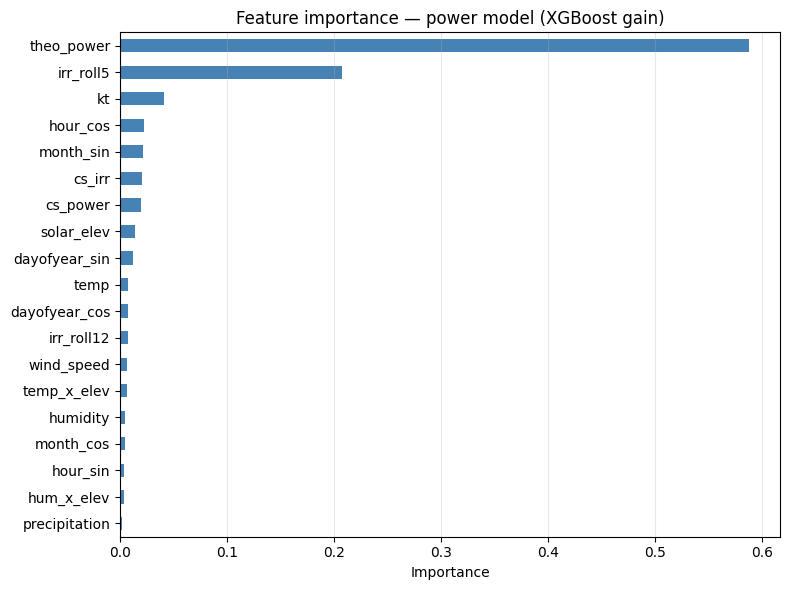

theo_power       0.5877
irr_roll5        0.2080
kt               0.0410
hour_cos         0.0227
month_sin        0.0218
cs_irr           0.0203
cs_power         0.0196
solar_elev       0.0142
dayofyear_sin    0.0118
temp             0.0077


In [12]:
fi = pd.Series(model.feature_importances_, index=FEATURES_FULL).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(8, 6))
fi.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature importance — power model (XGBoost gain)")
ax.set_xlabel("Importance"); ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()
print(fi.sort_values(ascending=False).head(10).round(4).to_string())


## 9. Day-level evaluation

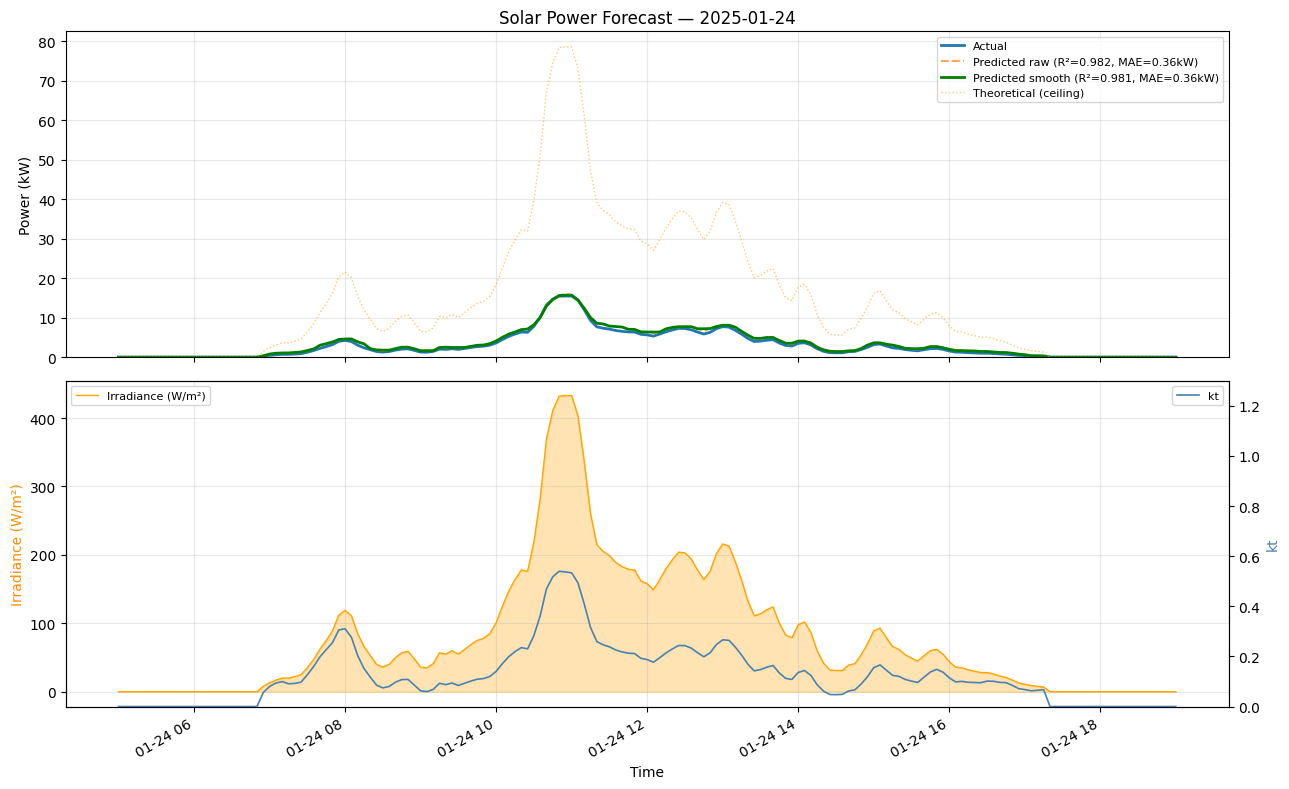

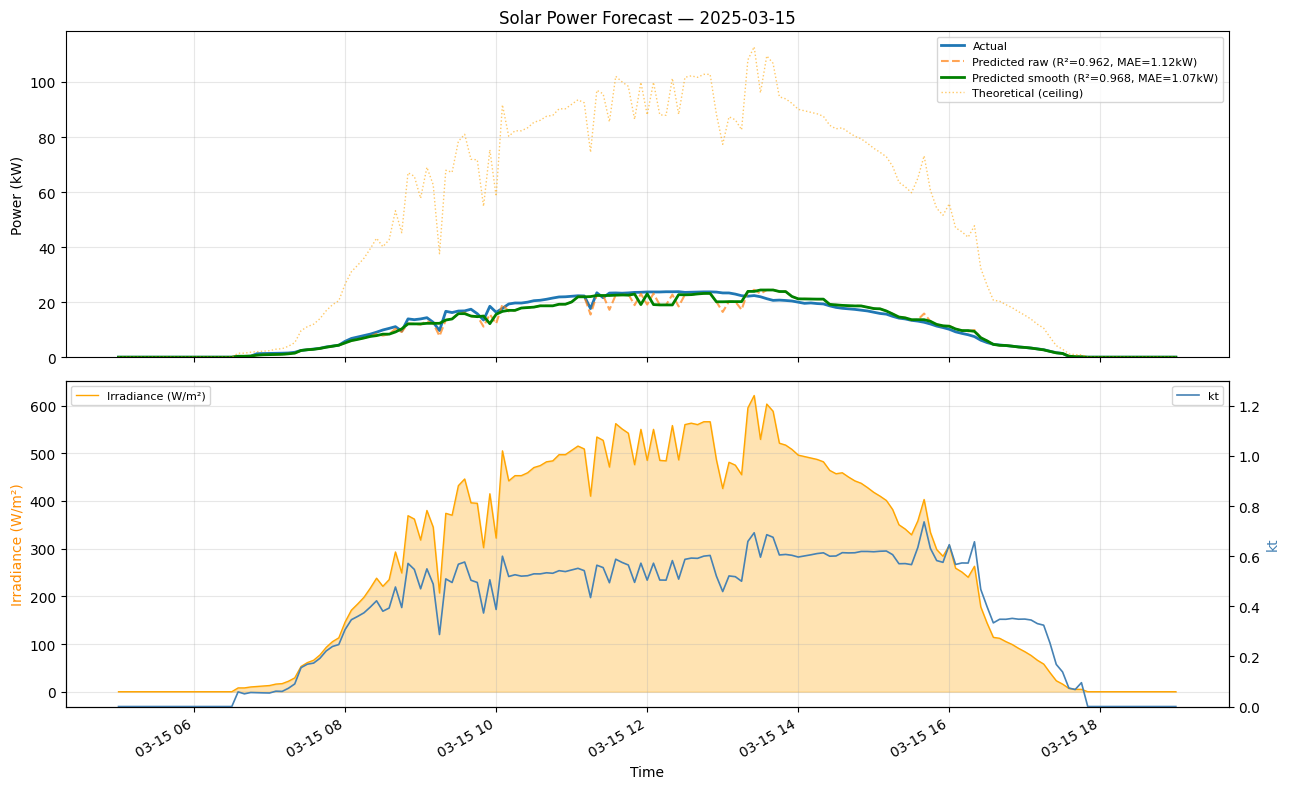

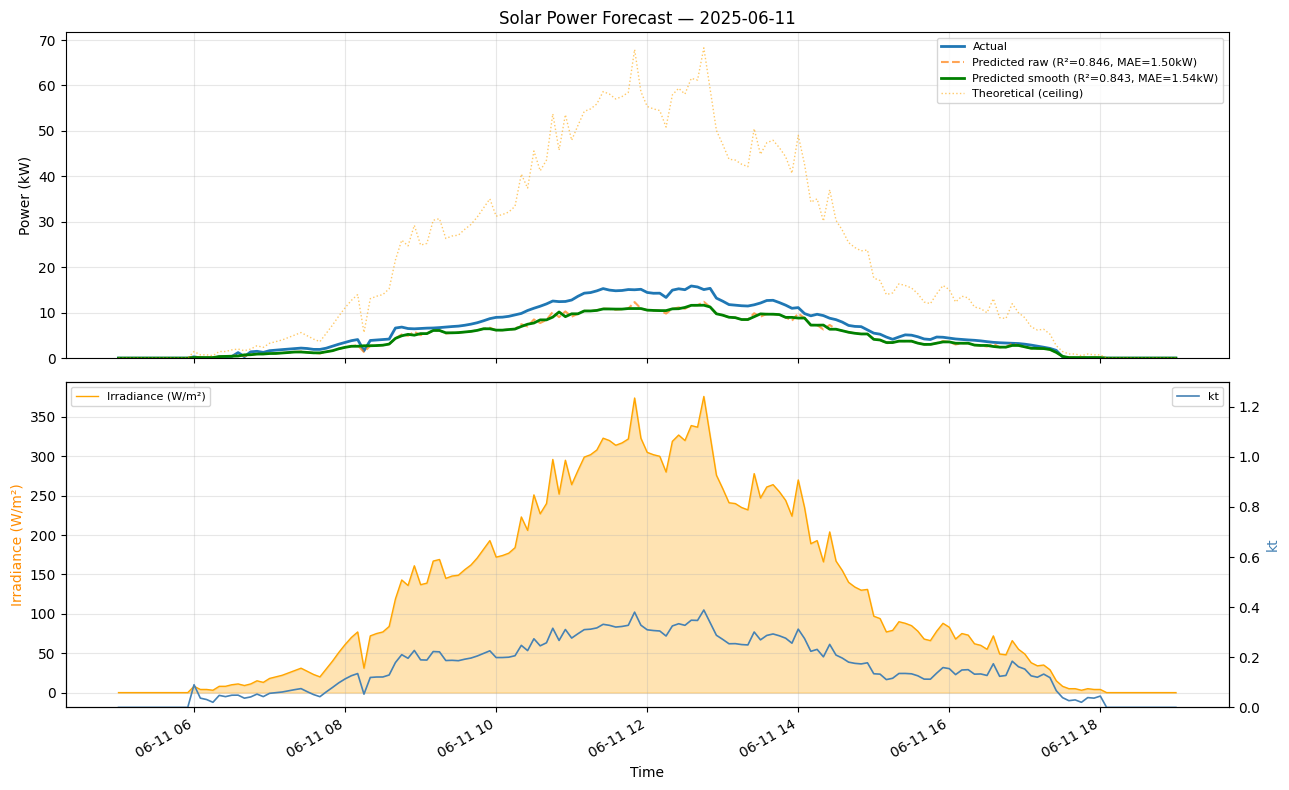

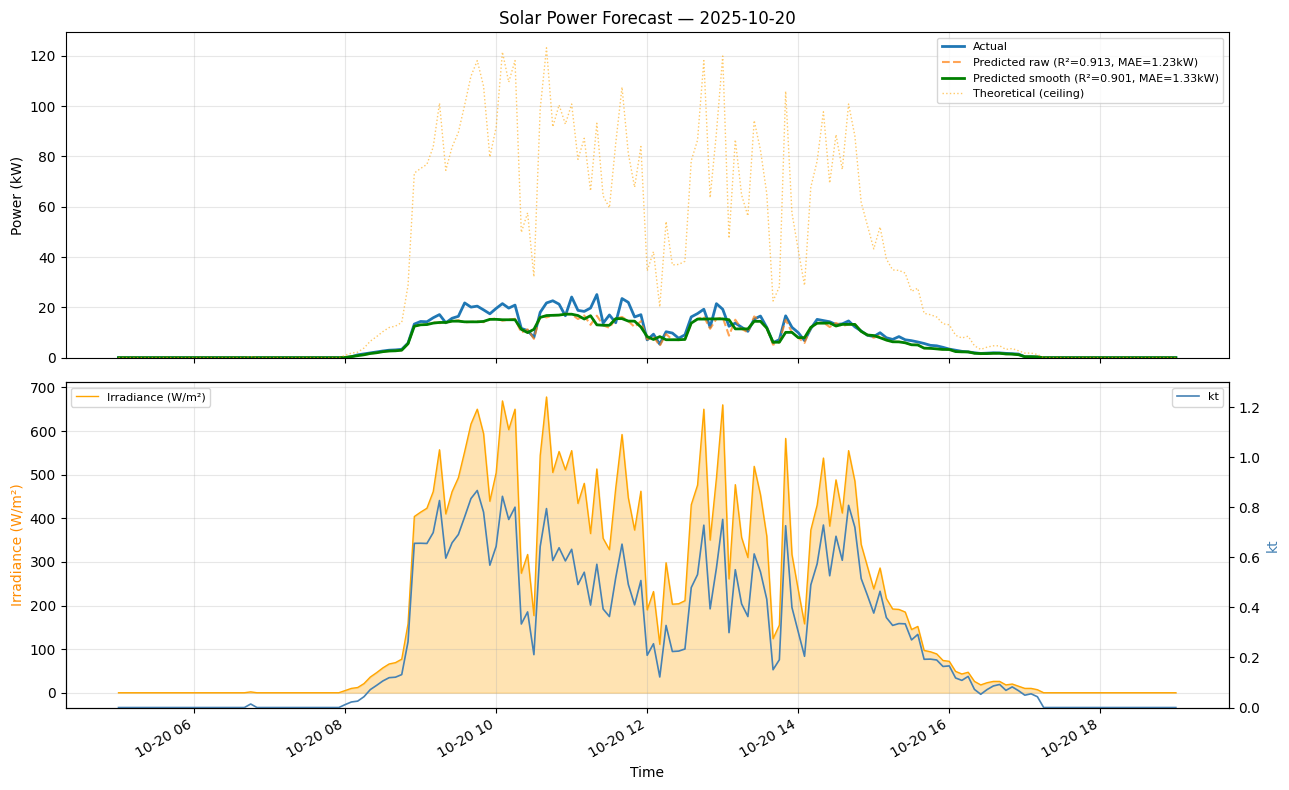

In [13]:
def plot_day_eval(date_string, smooth_window=3):
    d   = pd.to_datetime(date_string).date()
    sel = test[test["time"].dt.date == d].copy()
    if sel.empty:
        print(f"No test data for {date_string}"); return

    raw_pred    = sel["predicted_power"].values.copy()
    smooth_pred = pd.Series(raw_pred).rolling(
        smooth_window, center=True, min_periods=1).median().values
    smooth_pred = np.minimum(np.clip(smooth_pred, 0, RATED_KW),
                             sel["theoretical_power"].values)

    r2_raw  = r2_score(sel["power"], raw_pred)
    r2_sm   = r2_score(sel["power"], smooth_pred)
    mae_raw = mean_absolute_error(sel["power"], raw_pred)
    mae_sm  = mean_absolute_error(sel["power"], smooth_pred)

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

    ax = axes[0]
    ax.plot(sel["time"], sel["power"], lw=2, label="Actual")
    ax.plot(sel["time"], raw_pred,    lw=1.5, ls="--", alpha=0.7,
            label=f"Predicted raw (R²={r2_raw:.3f}, MAE={mae_raw:.2f}kW)")
    ax.plot(sel["time"], smooth_pred, lw=2, color="green",
            label=f"Predicted smooth (R²={r2_sm:.3f}, MAE={mae_sm:.2f}kW)")
    ax.plot(sel["time"], sel["theoretical_power"], lw=1, ls=":",
            color="orange", alpha=0.6, label="Theoretical (ceiling)")
    ax.set_ylabel("Power (kW)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_ylim(0); ax.set_title(f"Solar Power Forecast — {date_string}")

    ax2 = axes[1]
    ax2.fill_between(sel["time"], sel["irradiance"], alpha=0.3, color="orange")
    ax2.plot(sel["time"], sel["irradiance"], lw=1, color="orange", label="Irradiance (W/m²)")
    ax2r = ax2.twinx()
    ax2r.plot(sel["time"], sel["kt"], lw=1.2, color="steelblue", label="kt")
    ax2r.set_ylim(0, 1.3); ax2r.set_ylabel("kt", color="steelblue")
    ax2.set_ylabel("Irradiance (W/m²)", color="darkorange")
    ax2.set_xlabel("Time"); ax2.grid(alpha=0.3)
    ax2.legend(loc="upper left", fontsize=8)
    ax2r.legend(loc="upper right", fontsize=8)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout(); plt.show()

for d in ["2025-01-24", "2025-03-15", "2025-06-11", "2025-10-20"]:
    try: plot_day_eval(d)
    except Exception as e: print(f"  {d}: {e}")


## 10. Stage-1 — dual kt estimator

**v5 improvements:**
- Trained on **real data only** (synthetic 484-day gap excluded)
- Adds `hum_anomaly` and `is_monsoon` as features  
- **Two separate models**: monsoon (Jun–Sep) and dry season (Oct–May)
- At inference, the correct model is selected automatically by month


In [14]:
# Daytime + real-data-only rows for kt training
train_real_day = train[(train["cs_irr"] > 10) & (train["is_synthetic"] == 0)].copy()
test_day       = test[test["cs_irr"] > 10].copy()

print(f"kt training rows (real + daytime): {len(train_real_day):,}")
print(f"  Monsoon rows : {(train_real_day['is_monsoon']==1).sum():,}")
print(f"  Dry-season rows: {(train_real_day['is_monsoon']==0).sum():,}")
print()

# ── Monsoon model (Jun–Sep) ───────────────────────────────────────────────
tr_mon  = train_real_day[train_real_day["is_monsoon"] == 1]
val_mon = test_day[test_day["is_monsoon"] == 1]

kt_model_monsoon = XGBRegressor(**KT_PARAMS)
kt_model_monsoon.fit(tr_mon[WEATHER_FEATS], tr_mon["kt"],
                     eval_set=[(val_mon[WEATHER_FEATS], val_mon["kt"])],
                     verbose=False)

p_mon_tr = np.clip(kt_model_monsoon.predict(tr_mon[WEATHER_FEATS]), 0, 1.2)
p_mon_te = np.clip(kt_model_monsoon.predict(val_mon[WEATHER_FEATS]), 0, 1.2)
print("Monsoon kt model:")
print(f"  Train R² = {r2_score(tr_mon['kt'], p_mon_tr):.4f}")
print(f"  Test  R² = {r2_score(val_mon['kt'], p_mon_te):.4f}  (was 0.245 in v4)")
print(f"  Best iter: {kt_model_monsoon.best_iteration}")
print()

# ── Dry-season model (Oct–May) ───────────────────────────────────────────
tr_dry  = train_real_day[train_real_day["is_monsoon"] == 0]
val_dry = test_day[test_day["is_monsoon"] == 0]

kt_model_dry = XGBRegressor(**KT_PARAMS)
kt_model_dry.fit(tr_dry[WEATHER_FEATS], tr_dry["kt"],
                 eval_set=[(val_dry[WEATHER_FEATS], val_dry["kt"])],
                 verbose=False)

p_dry_tr = np.clip(kt_model_dry.predict(tr_dry[WEATHER_FEATS]), 0, 1.2)
p_dry_te = np.clip(kt_model_dry.predict(val_dry[WEATHER_FEATS]), 0, 1.2)
print("Dry-season kt model:")
print(f"  Train R² = {r2_score(tr_dry['kt'], p_dry_tr):.4f}")
print(f"  Test  R² = {r2_score(val_dry['kt'], p_dry_te):.4f}")
print(f"  Best iter: {kt_model_dry.best_iteration}")
print()

# ── Combined score ────────────────────────────────────────────────────────
all_pred = pd.concat([pd.Series(p_mon_te, index=val_mon.index),
                       pd.Series(p_dry_te, index=val_dry.index)]).sort_index()
all_true = test_day["kt"].loc[all_pred.index]
print(f"Combined dual model test R² = {r2_score(all_true, all_pred):.4f}  (v4 was 0.245)")

# Feature importance — monsoon model
fi_mon = pd.Series(kt_model_monsoon.feature_importances_,
                    index=WEATHER_FEATS).sort_values(ascending=False)
print("\nMonsoon kt model top features:")
print(fi_mon.head(6).round(4).to_string())


kt training rows (real + daytime): 85,282
  Monsoon rows : 23,928
  Dry-season rows: 61,354

Monsoon kt model:
  Train R² = 0.5498
  Test  R² = 0.4252  (was 0.245 in v4)
  Best iter: 44

Dry-season kt model:
  Train R² = 0.5105
  Test  R² = 0.2305
  Best iter: 28

Combined dual model test R² = 0.2686  (v4 was 0.245)

Monsoon kt model top features:
hour_cos         0.4775
solar_elev       0.1854
dayofyear_sin    0.0552
dayofyear_cos    0.0433
hour_sin         0.0422
month_cos        0.0348


## 11. compute_features and forecast function (v5)

In [15]:
def compute_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """Compute all features from weather + timestamp. Used in forecast pipeline."""
    df_in = df_in.copy()
    df_in["hour"]      = df_in["time"].dt.hour + df_in["time"].dt.minute / 60
    df_in["dayofyear"] = df_in["time"].dt.dayofyear
    df_in["month"]     = df_in["time"].dt.month

    for col, period in [("hour", 24), ("dayofyear", 365), ("month", 12)]:
        df_in[f"{col}_sin"] = np.sin(2 * np.pi * df_in[col] / period)
        df_in[f"{col}_cos"] = np.cos(2 * np.pi * df_in[col] / period)

    lat_r  = np.radians(LATITUDE)
    decl   = np.radians(23.45) * np.sin(np.radians((360/365) * (df_in["dayofyear"] - 81)))
    ha     = np.radians(15 * (df_in["hour"] - 12))
    sin_e  = np.sin(lat_r)*np.sin(decl) + np.cos(lat_r)*np.cos(decl)*np.cos(ha)
    df_in["solar_elev"] = np.degrees(np.arcsin(np.clip(sin_e, -1, 1)))
    df_in["cs_irr"]     = np.clip(1000 * sin_e, 0, 1100)
    df_in["cs_power"]   = df_in["cs_irr"] * AREA_EFF / 1000

    # v5: humidity anomaly using monthly means from training data
    monthly_hum_map = (
        train.groupby("month")["humidity"].mean().to_dict()
    )
    df_in["hum_monthly_mean"] = df_in["month"].map(monthly_hum_map).fillna(
        df_in["humidity"].mean()
    )
    df_in["hum_anomaly"] = df_in["humidity"] - df_in["hum_monthly_mean"]
    df_in["is_monsoon"]  = df_in["month"].isin([6, 7, 8, 9]).astype(int)

    # v5: use DUAL kt model — pick by season
    monsoon_mask = df_in["is_monsoon"].values.astype(bool)
    kt_vals = np.zeros(len(df_in))
    if monsoon_mask.any():
        kt_vals[monsoon_mask] = np.clip(
            kt_model_monsoon.predict(df_in.loc[monsoon_mask, WEATHER_FEATS]), 0, 1.2)
    if (~monsoon_mask).any():
        kt_vals[~monsoon_mask] = np.clip(
            kt_model_dry.predict(df_in.loc[~monsoon_mask, WEATHER_FEATS]), 0, 1.2)
    df_in["kt"] = kt_vals
    df_in.loc[df_in["solar_elev"] <= 0, "kt"] = 0.0

    # Derived solar features
    df_in["irradiance"]  = np.round(df_in["cs_irr"] * df_in["kt"]).astype(int).clip(0, 1100)
    df_in["theo_power"]  = df_in["irradiance"] * AREA_EFF / 1000
    df_in["irr_roll5"]   = df_in["irradiance"].rolling(5,  min_periods=1).mean()
    df_in["irr_roll12"]  = df_in["irradiance"].rolling(12, min_periods=1).mean()
    df_in["temp_x_elev"] = df_in["temp"]     * np.clip(sin_e, 0, 1)
    df_in["hum_x_elev"]  = df_in["humidity"] * np.clip(sin_e, 0, 1)
    return df_in


def forecast_from_hourly(date_string: str, hourly_data: list,
                          smooth_window: int = 3) -> pd.DataFrame:
    """Hourly weather → 5-min solar power forecast."""
    hourly = pd.DataFrame(hourly_data,
                          columns=["time","temp","humidity","wind_speed","precipitation"])
    hourly["time"] = pd.to_datetime(hourly["time"])

    t5  = pd.date_range(f"{date_string} 05:00", f"{date_string} 19:00", freq="5min")
    t_h = hourly["time"].astype("int64") // 10**9
    t_q = t5.astype("int64") // 10**9
    fm  = pd.DataFrame({"time": t5})

    for col in ["temp", "humidity", "wind_speed"]:
        fn  = PchipInterpolator(t_h, hourly[col].values, extrapolate=False)
        v   = fn(t_q.astype(float))
        v   = np.where(np.isnan(v), np.interp(t_q, t_h, hourly[col].values), v)
        fm[col] = v
    fm["humidity"]   = fm["humidity"].clip(0, 100)
    fm["wind_speed"] = fm["wind_speed"].clip(0)

    prec = np.zeros(len(t5))
    for _, row in hourly.iterrows():
        m = (fm["time"].dt.floor("h") == row["time"].floor("h")).values
        if m.sum() > 0 and row["precipitation"] > 0:
            prec[m] = row["precipitation"] / m.sum()
    fm["precipitation"] = np.round(prec, 4)

    fm = compute_features(fm)

    raw    = np.clip(model.predict(fm[FEATURES_FULL]), 0, RATED_KW)
    raw    = np.minimum(raw, fm["theo_power"].values)
    raw[fm["solar_elev"].values <= 0] = 0.0
    smooth = pd.Series(raw).rolling(smooth_window, center=True, min_periods=1).median().values
    smooth = np.clip(smooth, 0, RATED_KW)
    fm["predicted_power"] = smooth

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
    ax = axes[0]
    ax.fill_between(fm["time"], 0, fm["predicted_power"], alpha=0.2, color="steelblue")
    ax.plot(fm["time"], fm["predicted_power"], lw=2, color="steelblue", label="Predicted power (kW)")
    ax.plot(fm["time"], fm["cs_power"], lw=1.2, ls=":", color="orange", alpha=0.7, label="Clear-sky ceiling")
    ax.axhline(RATED_KW, lw=0.8, ls="--", color="red", alpha=0.4, label=f"Rated {RATED_KW:.1f} kW")
    ax.set_ylabel("Power (kW)"); ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_ylim(0); ax.set_title(f"Solar Power Forecast — {date_string}")

    ax2  = axes[1]
    c1, c2 = "darkorange", "steelblue"
    ln1  = ax2.plot(fm["time"], fm["irradiance"], color=c1, lw=1.5, label="Est. irradiance (W/m²)")
    ax2.set_ylabel("Irradiance (W/m²)", color=c1); ax2.tick_params(axis="y", labelcolor=c1)
    ax2r = ax2.twinx()
    ln2  = ax2r.plot(fm["time"], fm["kt"], color=c2, lw=1.2, ls="--", label="Cloud factor (kt)")
    ax2r.set_ylabel("kt", color=c2); ax2r.set_ylim(0, 1.3); ax2r.tick_params(axis="y", labelcolor=c2)
    ax2.legend(ln1+ln2, ["Est. irradiance", "kt"], fontsize=9, loc="upper left")
    ax2.grid(alpha=0.3); ax2.set_xlabel("Time (IST)")
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
    plt.tight_layout(); plt.show()

    peak   = fm["predicted_power"].max()
    energy = fm["predicted_power"].sum() * 5 / 60
    print(f"Peak power  : {peak:.2f} kW")
    print(f"Total energy: {energy:.2f} kWh")
    return fm[["time","predicted_power","irradiance","kt","cs_power"]]


## 12. Forecasts from hourly weather — Sep 2026 and Feb 2027

Compare these outputs with v4: the dual kt model should give higher peaks, especially on the Sep 2026 (monsoon) day.

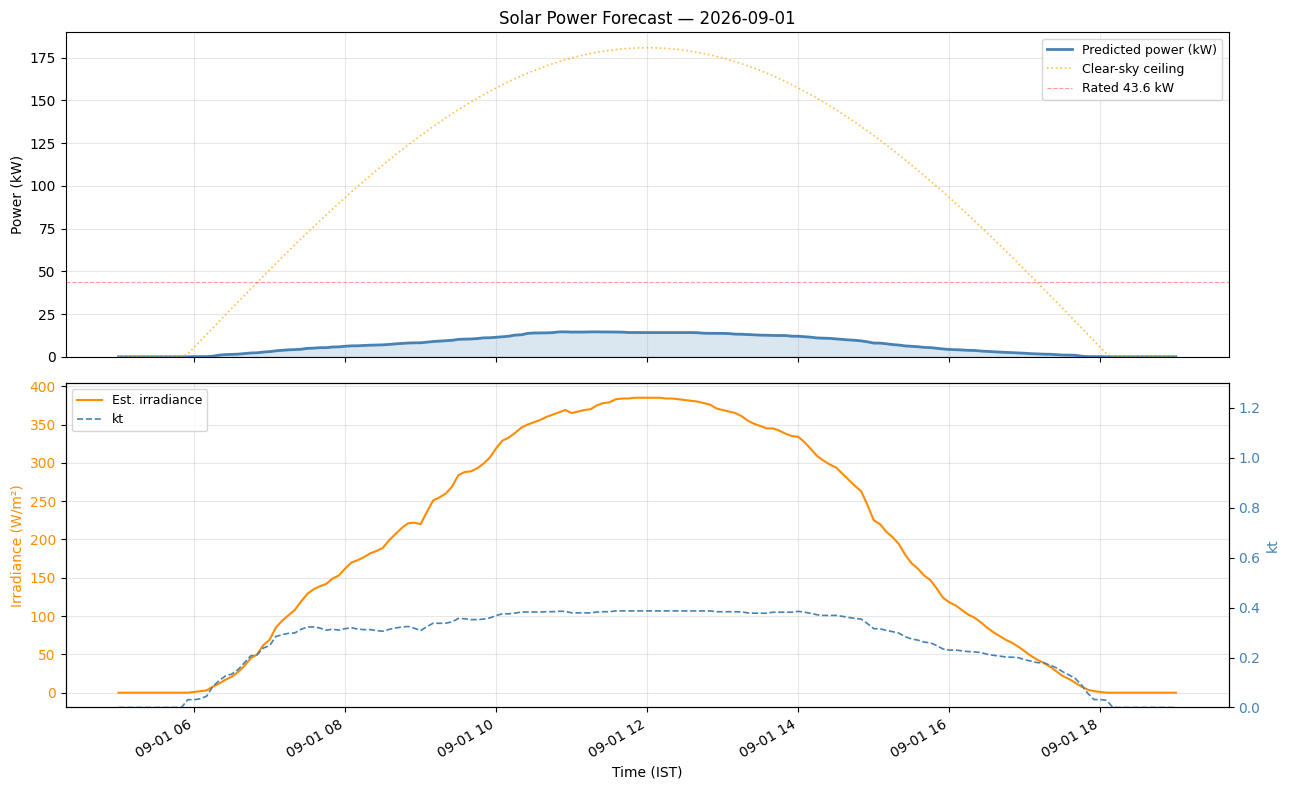

Peak power  : 14.60 kW
Total energy: 98.90 kWh


In [16]:
data_sep = [
    ("2026-09-01T00:00",25.4,92,13.4,0.1),
    ("2026-09-01T01:00",24.6,95,12.5,0.9),
    ("2026-09-01T02:00",24.4,96,11.2,0.9),
    ("2026-09-01T03:00",24.4,96,11.2,0.3),
    ("2026-09-01T04:00",24.5,95,10.6,0  ),
    ("2026-09-01T05:00",24.6,95,11.1,0  ),
    ("2026-09-01T06:00",26.1,91, 9.5,0  ),
    ("2026-09-01T07:00",26.9,90, 9.0,0  ),
    ("2026-09-01T08:00",27.5,87, 7.1,0  ),
    ("2026-09-01T09:00",28.8,79,10.1,0.5),
    ("2026-09-01T10:00",29.5,71,13.8,0  ),
    ("2026-09-01T11:00",28.9,72,18.4,0.1),
    ("2026-09-01T12:00",28.8,76,11.4,0.3),
    ("2026-09-01T13:00",29.2,74,12.5,0.2),
    ("2026-09-01T14:00",29.9,70,11.8,0  ),
    ("2026-09-01T15:00",30.8,66,10.0,0  ),
    ("2026-09-01T16:00",31.1,64,10.6,0  ),
    ("2026-09-01T17:00",30.4,68, 8.9,0  ),
    ("2026-09-01T18:00",28.5,84, 2.4,0  ),
    ("2026-09-01T19:00",27.8,86, 2.7,0  ),
    ("2026-09-01T20:00",27.4,87, 1.7,0.2),
    ("2026-09-01T21:00",27.2,87, 3.7,0  ),
    ("2026-09-01T22:00",27.2,87, 2.7,0  ),
    ("2026-09-01T23:00",26.8,85, 7.4,0  ),
    ("2026-09-02T00:00",26.3,86, 6.1,0  ),
]
_ = forecast_from_hourly("2026-09-01", data_sep)


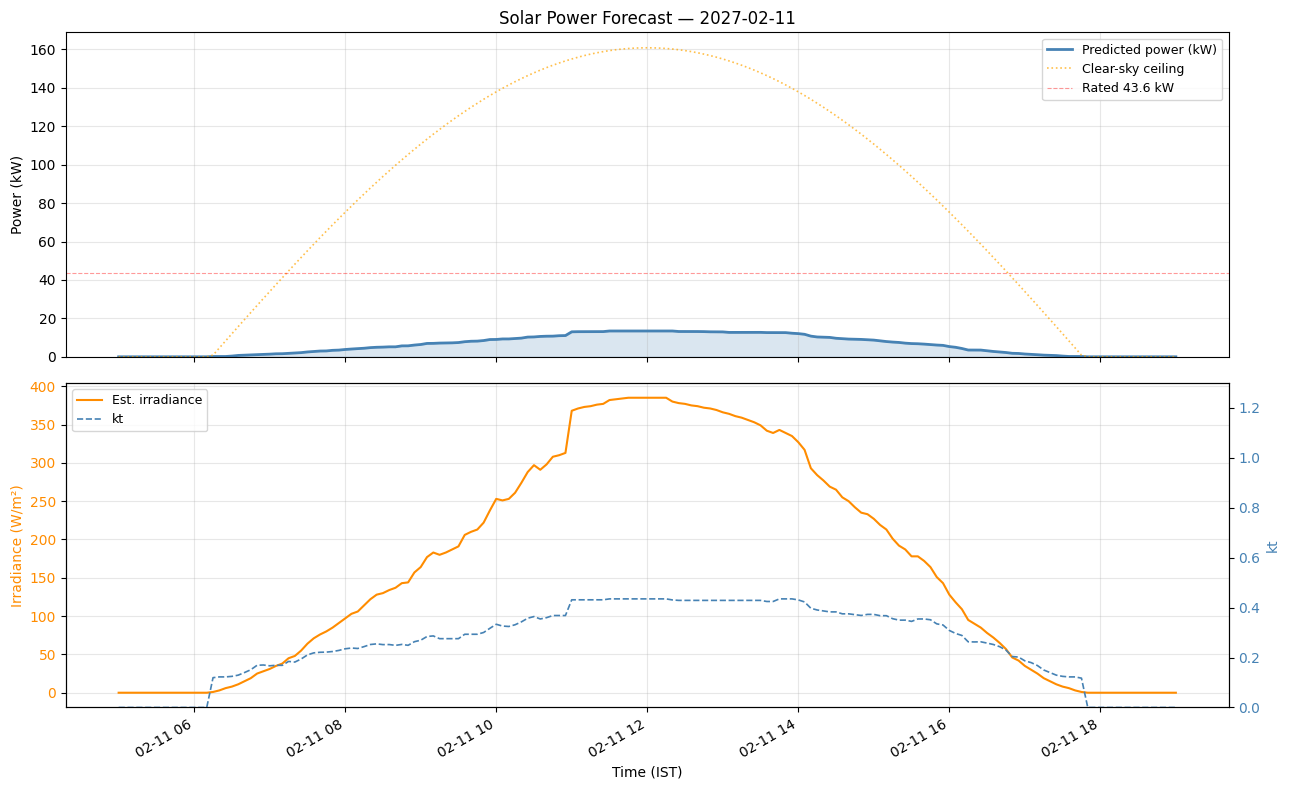

Peak power  : 13.44 kW
Total energy: 85.83 kWh


In [17]:
data_feb = [
    ("2027-02-10T23:00",28.1,80, 6.1,0  ),
    ("2027-02-11T00:00",27.8,81, 4.4,0  ),
    ("2027-02-11T01:00",27.5,82, 4.8,0.1),
    ("2027-02-11T02:00",27.5,82, 4.9,0  ),
    ("2027-02-11T03:00",26.9,85, 4.0,0  ),
    ("2027-02-11T04:00",26.5,88, 5.4,0  ),
    ("2027-02-11T05:00",26.5,89, 5.6,0.1),
    ("2027-02-11T06:00",27.5,83, 4.8,0  ),
    ("2027-02-11T07:00",28.5,77, 6.2,0.1),
    ("2027-02-11T08:00",29.5,73,10.2,0.1),
    ("2027-02-11T09:00",29.5,71,11.0,1.6),
    ("2027-02-11T10:00",29.3,73,10.2,0.4),
    ("2027-02-11T11:00",31.2,64,13.3,0  ),
    ("2027-02-11T12:00",31.5,64,13.7,0  ),
    ("2027-02-11T13:00",31.8,63,14.4,0  ),
    ("2027-02-11T14:00",31.5,64,15.2,0  ),
    ("2027-02-11T15:00",31.1,65,14.8,0  ),
    ("2027-02-11T16:00",30.2,70,14.9,0  ),
    ("2027-02-11T17:00",29.2,71,13.4,0  ),
    ("2027-02-11T18:00",28.1,78,11.3,0  ),
    ("2027-02-11T19:00",28.0,81, 8.9,0  ),
    ("2027-02-11T20:00",27.8,83, 7.6,0  ),
    ("2027-02-11T21:00",27.6,84, 5.7,0  ),
    ("2027-02-11T22:00",27.1,87, 4.4,0  ),
    ("2027-02-11T23:00",27.0,87, 5.4,0  ),
    ("2027-02-12T00:00",27.0,86, 5.5,0  ),
]
_ = forecast_from_hourly("2027-02-11", data_feb)


## 13. Monthly R² breakdown

In [18]:
test["month_name"] = test["time"].dt.strftime("%Y-%m")
monthly = {}
for m, grp in test.groupby("month_name"):
    y = grp["power"]; p = grp["predicted_power"]
    monthly[m] = {"R²": round(r2_score(y, p), 3),
                  "MAE": round(mean_absolute_error(y, p), 3),
                  "rows": len(y)}
print(pd.DataFrame(monthly).T.to_string())


            R²    MAE    rows
2024-12  1.000  0.000   676.0
2025-01  0.995  0.041  5239.0
2025-02  0.971  0.680  4732.0
2025-03  0.963  0.922  5239.0
2025-04  0.948  1.052  5070.0
2025-05  0.908  1.334  5239.0
2025-06  0.941  1.105  5070.0
2025-07  0.959  0.914  5239.0
2025-08  0.944  1.008  5239.0
2025-09  0.932  1.130  5070.0
2025-10  0.943  0.874  5239.0
2025-11  0.959  0.688  5070.0
2025-12  0.954  0.742  5239.0
2026-01  0.961  0.714  5239.0
2026-02  0.940  0.994  4732.0
2026-03  0.957  0.979  5239.0
2026-04  0.945  1.146  2028.0


## 14. Save models

In [19]:
save_dir = r"C:\Solar_SUDHA_maam\models"
os.makedirs(save_dir, exist_ok=True)

with open(os.path.join(save_dir, "power_model_v5.pkl"),    "wb") as f: pickle.dump(model, f)
with open(os.path.join(save_dir, "kt_model_monsoon_v5.pkl"),"wb") as f: pickle.dump(kt_model_monsoon, f)
with open(os.path.join(save_dir, "kt_model_dry_v5.pkl"),   "wb") as f: pickle.dump(kt_model_dry, f)

print("Models saved:")
print(f"  power_model_v5.pkl        — {len(FEATURES_FULL)} features, best_iter={model.best_iteration}")
print(f"  kt_model_monsoon_v5.pkl   — {len(WEATHER_FEATS)} features, Jun–Sep")
print(f"  kt_model_dry_v5.pkl       — {len(WEATHER_FEATS)} features, Oct–May")


Models saved:
  power_model_v5.pkl        — 19 features, best_iter=86
  kt_model_monsoon_v5.pkl   — 13 features, Jun–Sep
  kt_model_dry_v5.pkl       — 13 features, Oct–May
